# 🧪 GenAI vs Agentic AI — Hands-On Lab
### Session 2: Architectural Differences & Banking Use Cases
**Author: Soma Kesara** | For Senior Technologists

This notebook brings the presentation concepts to life through interactive simulations.
No external API calls required — everything runs locally with standard Python.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import time
import random
import json
from datetime import datetime, timedelta
from collections import defaultdict

# Consistent styling
PURPLE = '#6B21A8'
LIGHT_PURPLE = '#C4B5FD'
DARK_BG = '#1E1B4B'
ACCENT = '#A78BFA'
GREEN = '#22C55E'
RED = '#EF4444'
ORANGE = '#F59E0B'
BLUE = '#3B82F6'

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
print('✅ Lab environment ready!')

✅ Lab environment ready!


---
## 🔬 Experiment 1: GenAI vs Agentic — Request Pattern Simulation

**Concept:** GenAI = stateless prompt→response. Agentic = stateful goal→plan→execute→verify loop.

We simulate a **credit application review** using both paradigms and visualize the execution flow.

In [2]:
# === Simulate GenAI approach: Human orchestrates each step ===

class GenAISystem:
    """Stateless prompt-response system. No memory between calls."""
    
    def __init__(self):
        self.call_count = 0
        self.log = []
    
    def call(self, prompt: str, context: dict = None) -> dict:
        """Each call is independent — human must provide all context."""
        self.call_count += 1
        time.sleep(0.05)  # Simulate latency
        
        # Simulate responses based on prompt keywords
        if 'credit score' in prompt.lower():
            result = {'response': 'Credit score: 742 (Good)', 'tokens': 150}
        elif 'dti' in prompt.lower() or 'debt-to-income' in prompt.lower():
            result = {'response': 'DTI ratio: 32% (within 43% limit)', 'tokens': 200}
        elif 'collateral' in prompt.lower():
            result = {'response': 'Property valued at $280K, LTV: 71.4%', 'tokens': 180}
        elif 'recommendation' in prompt.lower():
            result = {'response': 'Recommend APPROVE with standard terms', 'tokens': 350}
        else:
            result = {'response': 'Generic analysis complete', 'tokens': 100}
        
        self.log.append({
            'step': self.call_count,
            'prompt': prompt[:60],
            'orchestrator': 'HUMAN',
            'time': time.time()
        })
        return result


# Run GenAI simulation
genai = GenAISystem()
print('=' * 60)
print('GenAI APPROACH — Human Orchestrates Every Step')
print('=' * 60)

steps = [
    "What's the credit score for applicant John Doe?",
    "Calculate DTI given income $120K and debts $2,400/mo",
    "Assess collateral value for property at 123 Main St",
    "Draft a recommendation based on: score=742, DTI=32%, LTV=71.4%"
]

genai_start = time.time()
for i, step in enumerate(steps):
    print(f'\n👤 Human asks (Step {i+1}): "{step}"')
    result = genai.call(step)
    print(f'🤖 AI responds: {result["response"]}')
    print(f'   [Human evaluates, decides next step...]')

genai_time = time.time() - genai_start
print(f'\n📊 Total: {genai.call_count} separate calls | {genai_time:.2f}s simulated')
print('   Human was orchestrator for EVERY interaction.')

GenAI APPROACH — Human Orchestrates Every Step

👤 Human asks (Step 1): "What's the credit score for applicant John Doe?"
🤖 AI responds: Credit score: 742 (Good)
   [Human evaluates, decides next step...]

👤 Human asks (Step 2): "Calculate DTI given income $120K and debts $2,400/mo"
🤖 AI responds: DTI ratio: 32% (within 43% limit)
   [Human evaluates, decides next step...]

👤 Human asks (Step 3): "Assess collateral value for property at 123 Main St"


🤖 AI responds: Property valued at $280K, LTV: 71.4%
   [Human evaluates, decides next step...]

👤 Human asks (Step 4): "Draft a recommendation based on: score=742, DTI=32%, LTV=71.4%"


🤖 AI responds: DTI ratio: 32% (within 43% limit)
   [Human evaluates, decides next step...]

📊 Total: 4 separate calls | 0.20s simulated
   Human was orchestrator for EVERY interaction.


In [3]:
# === Simulate Agentic approach: AI orchestrates toward goal ===

class AgenticSystem:
    """Stateful, goal-driven agent with planning, tool use, memory, reflection."""
    
    def __init__(self):
        self.memory = {}  # Persists across steps
        self.plan = []
        self.execution_log = []
        self.tools_called = []
    
    def set_goal(self, goal: str):
        print(f'\n🎯 GOAL SET: "{goal}"')
        self.plan = self._create_plan(goal)
        print(f'📋 PLAN CREATED ({len(self.plan)} steps):')
        for i, step in enumerate(self.plan):
            deps = step.get('depends_on', [])
            dep_str = f' [depends on: {deps}]' if deps else ' [no deps]'
            print(f'   {i+1}. {step["action"]}{dep_str}')
    
    def _create_plan(self, goal):
        """AI decomposes goal into subtasks with dependencies."""
        return [
            {'action': 'Retrieve application data', 'tool': 'loan_api', 'depends_on': []},
            {'action': 'Verify identity (KYC)', 'tool': 'kyc_api', 'depends_on': [1]},
            {'action': 'Pull credit report', 'tool': 'credit_bureau', 'depends_on': [1]},
            {'action': 'Calculate DTI ratio', 'tool': 'calculator', 'depends_on': [1, 3]},
            {'action': 'Check sanctions list', 'tool': 'sanctions_api', 'depends_on': [2]},
            {'action': 'Assess collateral', 'tool': 'property_api', 'depends_on': [1]},
            {'action': 'Generate decision', 'tool': 'underwriting_engine', 'depends_on': [2,3,4,5,6]},
        ]
    
    def execute(self):
        """Autonomous execution with self-verification."""
        print(f'\n🚀 EXECUTING AUTONOMOUSLY...')
        results = {}
        
        for i, step in enumerate(self.plan):
            time.sleep(0.03)  # Simulate tool call
            tool = step['tool']
            self.tools_called.append(tool)
            
            # Simulate tool results
            result = self._call_tool(tool, i+1)
            results[i+1] = result
            self.memory[step['action']] = result
            
            status = '✅' if result['success'] else '❌'
            print(f'   {status} Step {i+1}: {step["action"]} → {result["summary"]}')
            
            # Self-verification
            if not result['success']:
                print(f'   🔄 SELF-CORRECTING: Retrying with fallback...')
                result = self._call_tool(tool + '_fallback', i+1)
                results[i+1] = result
                print(f'   ✅ Retry successful: {result["summary"]}')
        
        self.execution_log = results
        return results
    
    def _call_tool(self, tool, step_num):
        tool_results = {
            'loan_api': {'success': True, 'summary': 'Applicant data retrieved (income: $120K)'},
            'kyc_api': {'success': True, 'summary': 'Identity verified, no adverse findings'},
            'credit_bureau': {'success': True, 'summary': 'Score: 742, no recent defaults'},
            'calculator': {'success': True, 'summary': 'DTI: 32% (within 43% policy limit)'},
            'sanctions_api': {'success': True, 'summary': 'No sanctions matches'},
            'property_api': {'success': True, 'summary': 'Property: $280K, LTV: 71.4%'},
            'underwriting_engine': {'success': True, 'summary': 'RECOMMEND APPROVE — all criteria met'},
        }
        return tool_results.get(tool, {'success': True, 'summary': 'Fallback succeeded'})


# Run Agentic simulation
agent = AgenticSystem()
print('=' * 60)
print('AGENTIC APPROACH — AI Orchestrates Toward Goal')
print('=' * 60)

agent_start = time.time()
agent.set_goal('Complete loan application review for #12345')
results = agent.execute()
agent_time = time.time() - agent_start

print(f'\n📊 Total: {len(agent.tools_called)} tool calls | {agent_time:.2f}s')
print(f'   AI orchestrated the ENTIRE workflow from a single goal.')
print(f'   Memory retained: {len(agent.memory)} context items across steps.')

AGENTIC APPROACH — AI Orchestrates Toward Goal

🎯 GOAL SET: "Complete loan application review for #12345"
📋 PLAN CREATED (7 steps):
   1. Retrieve application data [no deps]
   2. Verify identity (KYC) [depends on: [1]]
   3. Pull credit report [depends on: [1]]
   4. Calculate DTI ratio [depends on: [1, 3]]
   5. Check sanctions list [depends on: [2]]
   6. Assess collateral [depends on: [1]]
   7. Generate decision [depends on: [2, 3, 4, 5, 6]]

🚀 EXECUTING AUTONOMOUSLY...
   ✅ Step 1: Retrieve application data → Applicant data retrieved (income: $120K)
   ✅ Step 2: Verify identity (KYC) → Identity verified, no adverse findings
   ✅ Step 3: Pull credit report → Score: 742, no recent defaults
   ✅ Step 4: Calculate DTI ratio → DTI: 32% (within 43% policy limit)


   ✅ Step 5: Check sanctions list → No sanctions matches
   ✅ Step 6: Assess collateral → Property: $280K, LTV: 71.4%


   ✅ Step 7: Generate decision → RECOMMEND APPROVE — all criteria met

📊 Total: 7 tool calls | 0.21s
   AI orchestrated the ENTIRE workflow from a single goal.
   Memory retained: 7 context items across steps.


/tmp/ipykernel_39/1126524742.py:66: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_39/1126524742.py:66: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_39/1126524742.py:66: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_39/1126524742.py:66: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_39/1126524742.py:66: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_39/1126524742.py:66: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_39/1126524742.py:66: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

/tmp/ipykernel_39/1126524742.py:67: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig('/home/claude/exp1_flow_comparison.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_39/1126524742.py:67: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  plt.savefig('/home/claude/exp1_flow_comparison.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_39/1126524742.py:67: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('/home/claude/exp1_flow_comparison.png', dpi=150, bbox_inches='tight')


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

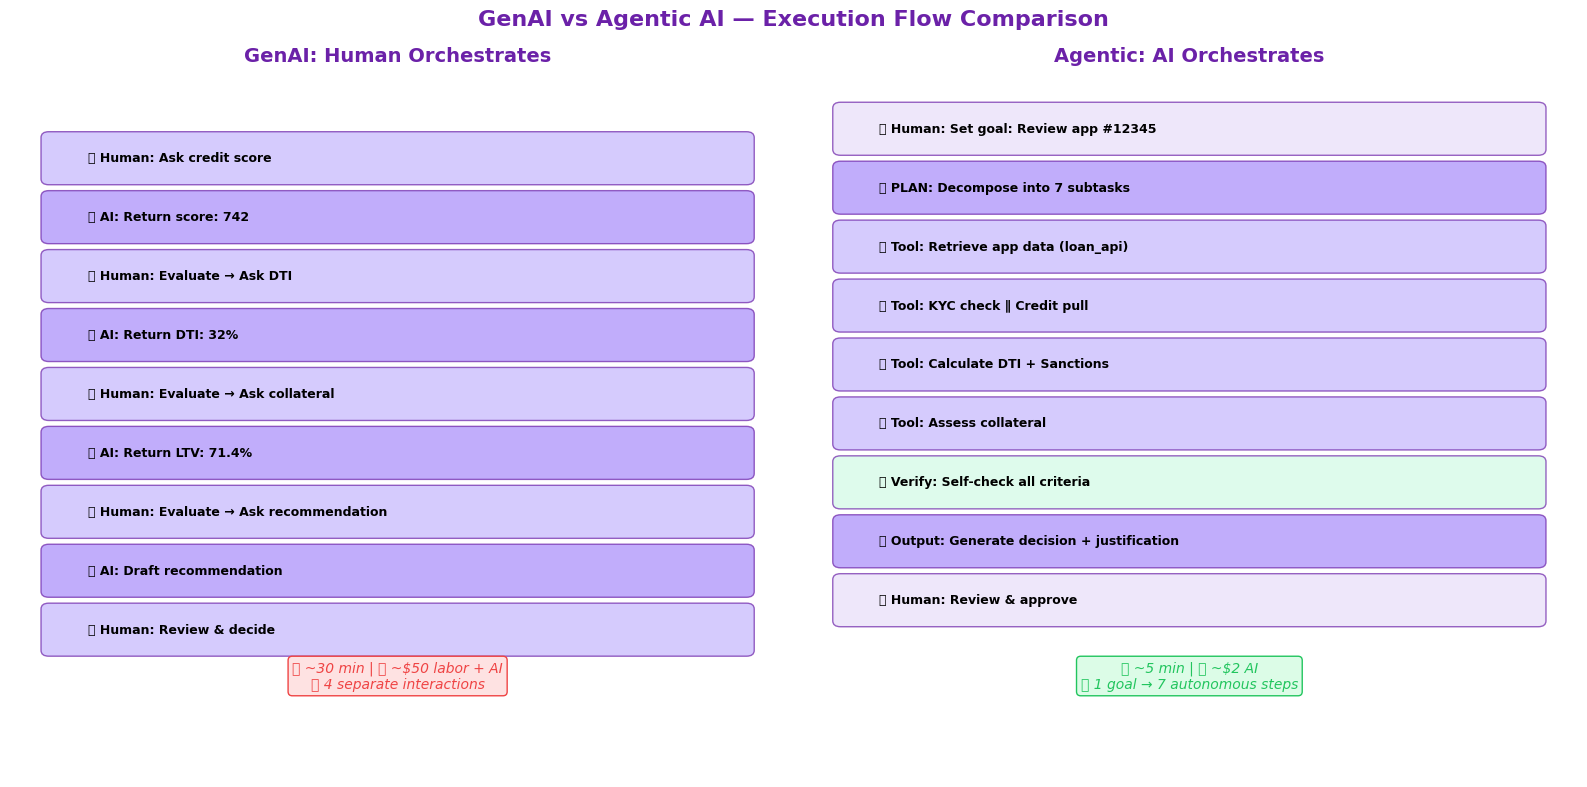

💡 Key insight: Same outcome, fundamentally different architecture.


In [4]:
# === VISUAL: Side-by-side execution flow comparison ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('GenAI vs Agentic AI — Execution Flow Comparison', 
             fontsize=16, fontweight='bold', color=PURPLE, y=0.98)

# --- GenAI Flow (Left) ---
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 12)
ax1.set_title('GenAI: Human Orchestrates', fontsize=14, fontweight='bold', color=PURPLE)
ax1.axis('off')

genai_steps = [
    ('👤 Human', 'Ask credit score', 10.5),
    ('🤖 AI', 'Return score: 742', 9.5),
    ('👤 Human', 'Evaluate → Ask DTI', 8.5),
    ('🤖 AI', 'Return DTI: 32%', 7.5),
    ('👤 Human', 'Evaluate → Ask collateral', 6.5),
    ('🤖 AI', 'Return LTV: 71.4%', 5.5),
    ('👤 Human', 'Evaluate → Ask recommendation', 4.5),
    ('🤖 AI', 'Draft recommendation', 3.5),
    ('👤 Human', 'Review & decide', 2.5),
]

for actor, action, y in genai_steps:
    color = LIGHT_PURPLE if '👤' in actor else ACCENT
    rect = FancyBboxPatch((0.5, y-0.35), 9, 0.7, 
                          boxstyle="round,pad=0.1", 
                          facecolor=color, edgecolor=PURPLE, alpha=0.7)
    ax1.add_patch(rect)
    ax1.text(1, y, f'{actor}: {action}', va='center', fontsize=9, fontweight='bold')

ax1.text(5, 1.5, '⏱ ~30 min | 💰 ~$50 labor + AI\n🔄 4 separate interactions',
         ha='center', fontsize=10, style='italic', color=RED,
         bbox=dict(boxstyle='round', facecolor='#FEE2E2', edgecolor=RED))

# --- Agentic Flow (Right) ---
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 12)
ax2.set_title('Agentic: AI Orchestrates', fontsize=14, fontweight='bold', color=PURPLE)
ax2.axis('off')

agentic_steps = [
    ('👤 Human', 'Set goal: Review app #12345', 11, '#E8DEF8'),
    ('🤖 PLAN', 'Decompose into 7 subtasks', 10, ACCENT),
    ('🔧 Tool', 'Retrieve app data (loan_api)', 9, LIGHT_PURPLE),
    ('🔧 Tool', 'KYC check ∥ Credit pull', 8, LIGHT_PURPLE),
    ('🔧 Tool', 'Calculate DTI + Sanctions', 7, LIGHT_PURPLE),
    ('🔧 Tool', 'Assess collateral', 6, LIGHT_PURPLE),
    ('🔍 Verify', 'Self-check all criteria', 5, '#D1FAE5'),
    ('📝 Output', 'Generate decision + justification', 4, ACCENT),
    ('👤 Human', 'Review & approve', 3, '#E8DEF8'),
]

for actor, action, y, color in agentic_steps:
    rect = FancyBboxPatch((0.5, y-0.35), 9, 0.7,
                          boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor=PURPLE, alpha=0.7)
    ax2.add_patch(rect)
    ax2.text(1, y, f'{actor}: {action}', va='center', fontsize=9, fontweight='bold')

ax2.text(5, 1.5, '⏱ ~5 min | 💰 ~$2 AI\n🎯 1 goal → 7 autonomous steps',
         ha='center', fontsize=10, style='italic', color=GREEN,
         bbox=dict(boxstyle='round', facecolor='#DCFCE7', edgecolor=GREEN))

plt.tight_layout()
plt.savefig('/home/claude/exp1_flow_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Key insight: Same outcome, fundamentally different architecture.')

---
## 🔬 Experiment 2: The Autonomy Spectrum — Banking Use Case Mapping

**Concept:** Autonomy is a dial (L0–L5), not a switch. Most banking systems operate at L1–L3.

We visualize where 12 banking use cases land on the spectrum.

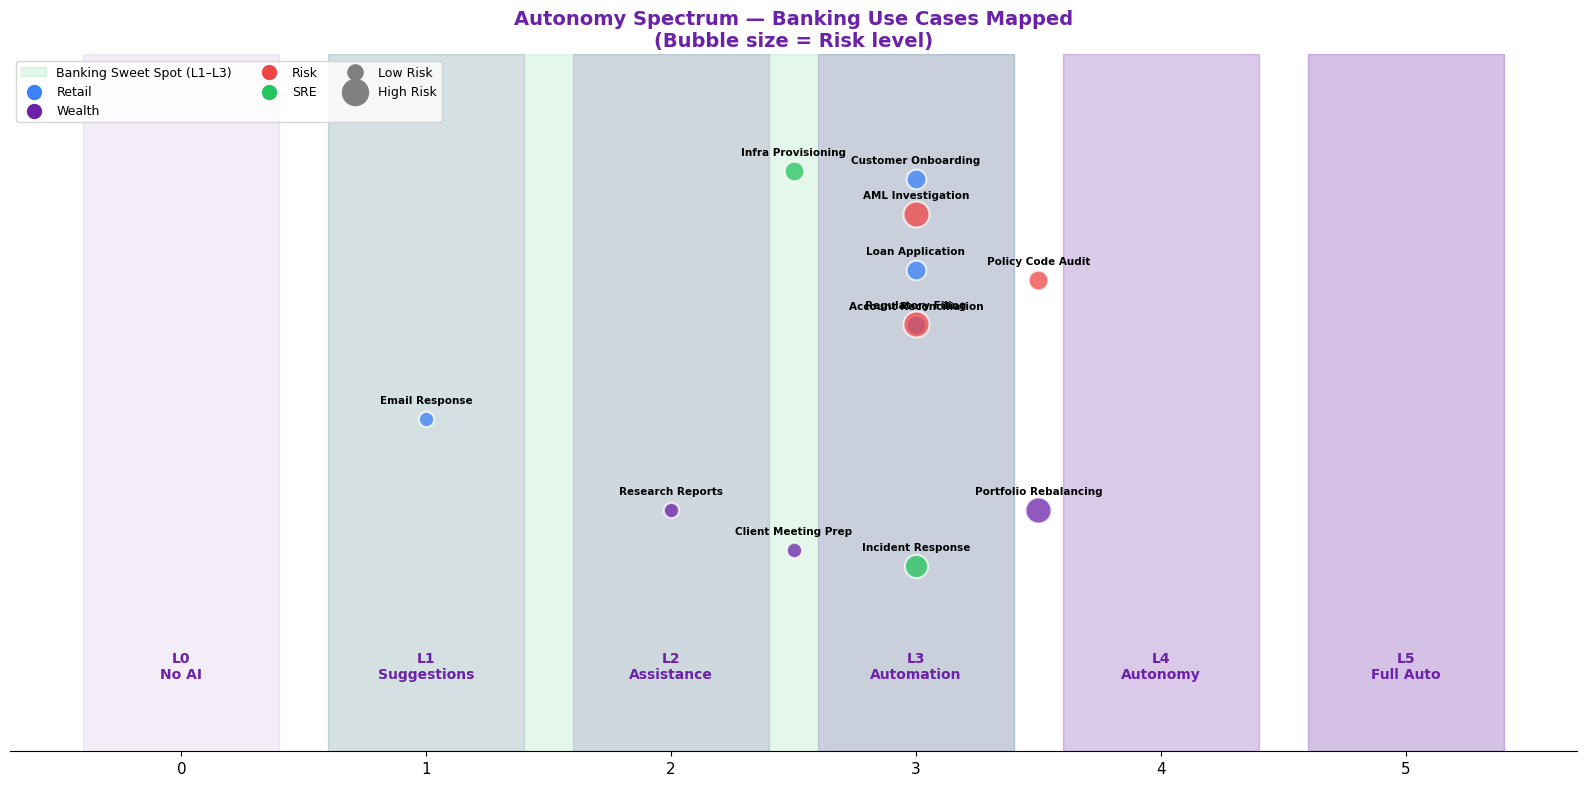

💡 Most banking use cases cluster at L2–L3. L5 is theoretical only.


In [5]:
# === Autonomy Spectrum Visualization ===

use_cases = [
    {'name': 'Email Response', 'domain': 'Retail', 'level': 1, 'risk': 'Low'},
    {'name': 'Customer Onboarding', 'domain': 'Retail', 'level': 3, 'risk': 'Med'},
    {'name': 'Loan Application', 'domain': 'Retail', 'level': 3, 'risk': 'Med'},
    {'name': 'Account Reconciliation', 'domain': 'Retail', 'level': 3, 'risk': 'Med'},
    {'name': 'Portfolio Rebalancing', 'domain': 'Wealth', 'level': 3.5, 'risk': 'High'},
    {'name': 'Research Reports', 'domain': 'Wealth', 'level': 2, 'risk': 'Low'},
    {'name': 'Client Meeting Prep', 'domain': 'Wealth', 'level': 2.5, 'risk': 'Low'},
    {'name': 'AML Investigation', 'domain': 'Risk', 'level': 3, 'risk': 'High'},
    {'name': 'Regulatory Filing', 'domain': 'Risk', 'level': 3, 'risk': 'High'},
    {'name': 'Policy Code Audit', 'domain': 'Risk', 'level': 3.5, 'risk': 'Med'},
    {'name': 'Incident Response', 'domain': 'SRE', 'level': 3, 'risk': 'Med-High'},
    {'name': 'Infra Provisioning', 'domain': 'SRE', 'level': 2.5, 'risk': 'Med'},
]

domain_colors = {'Retail': BLUE, 'Wealth': PURPLE, 'Risk': RED, 'SRE': GREEN}
risk_sizes = {'Low': 120, 'Med': 200, 'Med-High': 280, 'High': 350}

fig, ax = plt.subplots(figsize=(16, 8))

# Background gradient for autonomy levels
for i in range(6):
    alpha = 0.08 + i * 0.04
    ax.axvspan(i - 0.4, i + 0.4, alpha=alpha, color=PURPLE)

# Banking sweet spot
ax.axvspan(0.6, 3.4, alpha=0.12, color=GREEN, label='Banking Sweet Spot (L1–L3)')

# Plot use cases with jitter
np.random.seed(42)
for i, uc in enumerate(use_cases):
    jitter_y = np.random.uniform(0.5, 4.5)
    color = domain_colors[uc['domain']]
    size = risk_sizes.get(uc['risk'], 200)
    ax.scatter(uc['level'], jitter_y, s=size, c=color, alpha=0.75, 
              edgecolors='white', linewidth=1.5, zorder=5)
    ax.annotate(uc['name'], (uc['level'], jitter_y), 
               fontsize=7.5, ha='center', va='bottom',
               xytext=(0, 10), textcoords='offset points',
               fontweight='bold')

# Level labels
level_labels = [
    'L0\nNo AI', 'L1\nSuggestions', 'L2\nAssistance', 
    'L3\nAutomation', 'L4\nAutonomy', 'L5\nFull Auto'
]
for i, label in enumerate(level_labels):
    ax.text(i, -0.5, label, ha='center', fontsize=10, fontweight='bold', color=PURPLE)

# Legend
for domain, color in domain_colors.items():
    ax.scatter([], [], c=color, s=100, label=domain)
ax.scatter([], [], c='gray', s=120, label='Low Risk')
ax.scatter([], [], c='gray', s=350, label='High Risk')

ax.legend(loc='upper left', fontsize=9, ncol=3)
ax.set_xlim(-0.7, 5.7)
ax.set_ylim(-1.2, 5.5)
ax.set_yticks([])
ax.set_title('Autonomy Spectrum — Banking Use Cases Mapped\n(Bubble size = Risk level)', 
             fontsize=14, fontweight='bold', color=PURPLE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig('/home/claude/exp2_autonomy_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Most banking use cases cluster at L2–L3. L5 is theoretical only.')

---
## 🔬 Experiment 3: Agentic AI Core Capabilities — Planning & Dependency Graph

**Concept:** Agents decompose goals into subtasks with dependencies, enabling parallel execution.

We build and visualize a dependency graph for a loan review agent.

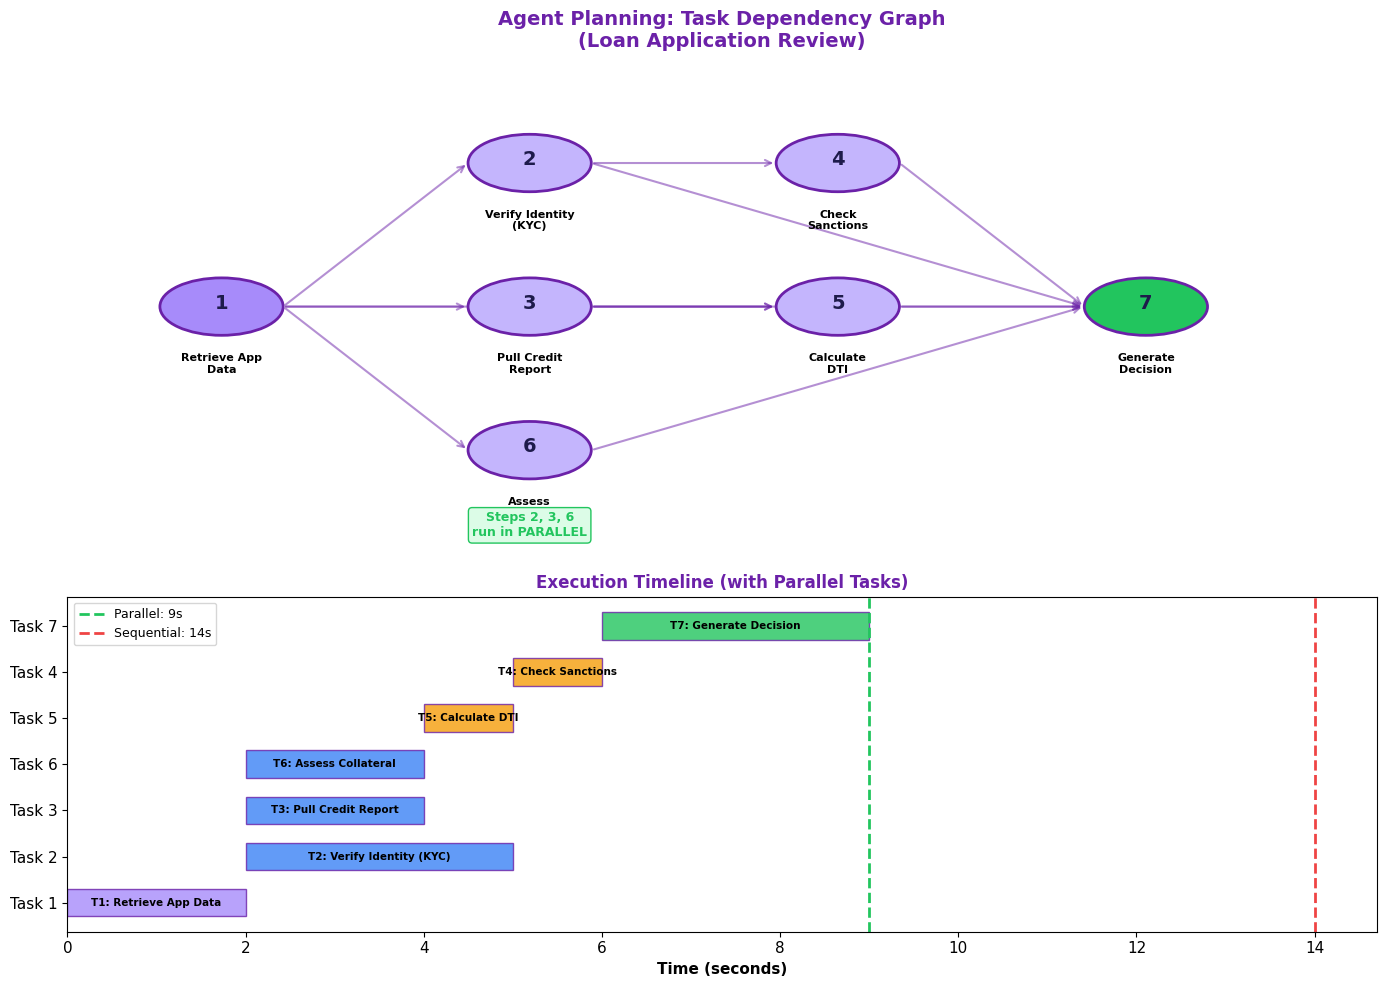

💡 Parallel execution saves 5s (36% faster)


In [6]:
# === Agent Planning: Dependency Graph for Loan Review ===

tasks = {
    1: {'name': 'Retrieve App\nData', 'deps': [], 'duration': 2, 'tool': 'loan_api'},
    2: {'name': 'Verify Identity\n(KYC)', 'deps': [1], 'duration': 3, 'tool': 'kyc_api'},
    3: {'name': 'Pull Credit\nReport', 'deps': [1], 'duration': 2, 'tool': 'credit_bureau'},
    4: {'name': 'Check\nSanctions', 'deps': [2], 'duration': 1, 'tool': 'sanctions_api'},
    5: {'name': 'Calculate\nDTI', 'deps': [1, 3], 'duration': 1, 'tool': 'calculator'},
    6: {'name': 'Assess\nCollateral', 'deps': [1], 'duration': 2, 'tool': 'property_api'},
    7: {'name': 'Generate\nDecision', 'deps': [2, 3, 4, 5, 6], 'duration': 3, 'tool': 'underwriting'},
}

# Calculate earliest start times (topological order)
start_times = {}
def calc_start(task_id):
    if task_id in start_times:
        return start_times[task_id]
    deps = tasks[task_id]['deps']
    if not deps:
        start_times[task_id] = 0
    else:
        start_times[task_id] = max(
            calc_start(d) + tasks[d]['duration'] for d in deps
        )
    return start_times[task_id]

for tid in tasks:
    calc_start(tid)

# Positions for visualization
positions = {
    1: (1, 3),
    2: (3, 5), 3: (3, 3), 6: (3, 1),
    4: (5, 5), 5: (5, 3),
    7: (7, 3),
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), 
                                gridspec_kw={'height_ratios': [3, 2]})

# --- Top: Dependency Graph ---
ax1.set_title('Agent Planning: Task Dependency Graph\n(Loan Application Review)', 
              fontsize=14, fontweight='bold', color=PURPLE)
ax1.set_xlim(0, 8.5)
ax1.set_ylim(-0.5, 6.5)
ax1.axis('off')

# Draw edges first
for tid, task in tasks.items():
    for dep in task['deps']:
        x1, y1 = positions[dep]
        x2, y2 = positions[tid]
        ax1.annotate('', xy=(x2-0.4, y2), xytext=(x1+0.4, y1),
                    arrowprops=dict(arrowstyle='->', color=PURPLE, lw=1.5, alpha=0.5))

# Draw nodes
for tid, task in tasks.items():
    x, y = positions[tid]
    color = GREEN if tid == 7 else (LIGHT_PURPLE if task['deps'] else ACCENT)
    circle = plt.Circle((x, y), 0.4, color=color, ec=PURPLE, lw=2, zorder=5)
    ax1.add_patch(circle)
    ax1.text(x, y + 0.05, str(tid), ha='center', va='center', fontsize=14, 
            fontweight='bold', color=DARK_BG, zorder=6)
    ax1.text(x, y - 0.65, task['name'], ha='center', va='top', fontsize=8,
            fontweight='bold')

# Parallel execution note
ax1.annotate('Steps 2, 3, 6\nrun in PARALLEL', xy=(3, 3), xytext=(3, -0.2),
            fontsize=9, ha='center', color=GREEN, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#DCFCE7', edgecolor=GREEN))

# --- Bottom: Gantt Chart ---
ax2.set_title('Execution Timeline (with Parallel Tasks)', 
              fontsize=12, fontweight='bold', color=PURPLE)

colors_map = {1: ACCENT, 2: BLUE, 3: BLUE, 4: ORANGE, 5: ORANGE, 6: BLUE, 7: GREEN}
sorted_tasks = sorted(tasks.keys(), key=lambda t: start_times[t])

for i, tid in enumerate(sorted_tasks):
    task = tasks[tid]
    start = start_times[tid]
    ax2.barh(i, task['duration'], left=start, height=0.6,
            color=colors_map[tid], edgecolor=PURPLE, alpha=0.8)
    ax2.text(start + task['duration']/2, i, 
            f"T{tid}: {task['name'].replace(chr(10), ' ')}",
            ha='center', va='center', fontsize=7.5, fontweight='bold')

total_time = max(start_times[t] + tasks[t]['duration'] for t in tasks)
sequential_time = sum(t['duration'] for t in tasks.values())

ax2.set_xlabel('Time (seconds)', fontweight='bold')
ax2.set_yticks(range(len(sorted_tasks)))
ax2.set_yticklabels([f'Task {t}' for t in sorted_tasks])
ax2.axvline(x=total_time, color=GREEN, linestyle='--', lw=2, label=f'Parallel: {total_time}s')
ax2.axvline(x=sequential_time, color=RED, linestyle='--', lw=2, label=f'Sequential: {sequential_time}s')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/home/claude/exp3_planning_deps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💡 Parallel execution saves {sequential_time - total_time}s ({(1-total_time/sequential_time)*100:.0f}% faster)')

---
## 🔬 Experiment 4: Tool Use & Error Handling Simulation

**Concept:** Agents must handle tool failures gracefully — retry, fallback, degrade, or escalate.

We simulate a fraud investigation agent encountering real-world failures.

🔍 Investigating transaction #98765 for fraud...

  ⚠️  get_transaction_details failed (attempt 1) — TIMEOUT
      Retrying with backoff...
  ✅ Pull transaction data [retry (attempt 2)]
  ✅ Get 90-day history [direct]
  ⚠️  check_fraud_score failed (attempt 1) — TIMEOUT
      Retrying with backoff...
  ✅ ML fraud scoring [retry (attempt 2)]
  ✅ Velocity anomaly check [direct]
  ⚠️  check_sanctions failed (attempt 1) — TIMEOUT
      Retrying with backoff...
  ✅ Sanctions screening [retry (attempt 2)]
  ✅ Create case if needed [direct]


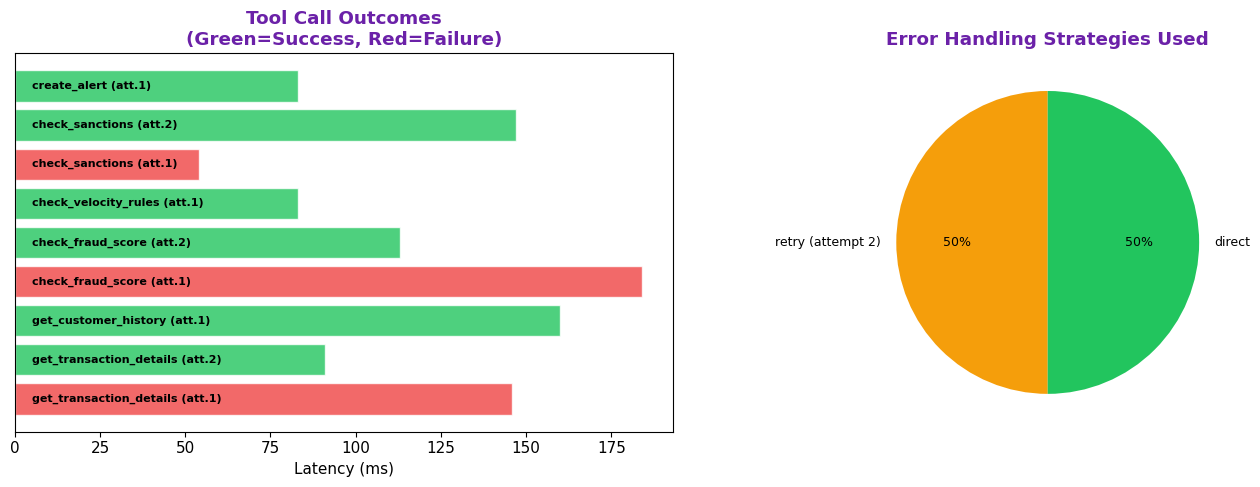

💡 Real agents need retry, fallback, degradation, AND escalation strategies.


In [7]:
# === Fraud Investigation Agent with Error Handling ===

class ToolRegistry:
    """Simulated banking tool registry with failure injection."""
    
    def __init__(self, failure_rate=0.3):
        self.failure_rate = failure_rate
        self.call_log = []
        random.seed(42)
    
    def call(self, tool_name, params=None, attempt=1):
        latency = random.uniform(0.05, 0.2)
        time.sleep(latency / 10)  # Scaled down for demo
        
        # Inject failures
        fails = random.random() < self.failure_rate and attempt == 1
        
        entry = {
            'tool': tool_name,
            'attempt': attempt,
            'success': not fails,
            'latency_ms': round(latency * 1000),
            'error': 'TIMEOUT' if fails else None
        }
        self.call_log.append(entry)
        return entry


class FraudInvestigationAgent:
    def __init__(self):
        self.tools = ToolRegistry(failure_rate=0.35)
        self.max_retries = 3
        self.investigation = []
    
    def investigate(self, transaction_id):
        print(f'🔍 Investigating transaction #{transaction_id} for fraud...\n')
        
        steps = [
            ('get_transaction_details', 'critical', 'Pull transaction data'),
            ('get_customer_history', 'important', 'Get 90-day history'),
            ('check_fraud_score', 'critical', 'ML fraud scoring'),
            ('check_velocity_rules', 'important', 'Velocity anomaly check'),
            ('check_sanctions', 'critical', 'Sanctions screening'),
            ('create_alert', 'important', 'Create case if needed'),
        ]
        
        for tool_name, criticality, description in steps:
            success = False
            strategy_used = 'direct'
            
            for attempt in range(1, self.max_retries + 1):
                result = self.tools.call(tool_name, attempt=attempt)
                
                if result['success']:
                    success = True
                    if attempt > 1:
                        strategy_used = f'retry (attempt {attempt})'
                    break
                else:
                    print(f'  ⚠️  {tool_name} failed (attempt {attempt}) — {result["error"]}')
                    if attempt < self.max_retries:
                        print(f'      Retrying with backoff...')
            
            if not success:
                if criticality == 'critical':
                    strategy_used = 'ESCALATED to human'
                    print(f'  🚨 CRITICAL: {tool_name} failed after {self.max_retries} retries → ESCALATING')
                else:
                    strategy_used = 'graceful degradation'
                    success = True  # Proceed without
                    print(f'  ℹ️  {tool_name} skipped (non-critical) → proceeding with available data')
            
            status = '✅' if success else '🚨'
            print(f'  {status} {description} [{strategy_used}]')
            
            self.investigation.append({
                'tool': tool_name, 'success': success,
                'strategy': strategy_used, 'criticality': criticality
            })
        
        return self.investigation


agent = FraudInvestigationAgent()
results = agent.investigate(98765)

# Visualize error handling strategies
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Tool call outcomes
tools = [r['tool'] for r in agent.tools.call_log]
successes = [r['success'] for r in agent.tools.call_log]
colors = [GREEN if s else RED for s in successes]
attempts = [r['attempt'] for r in agent.tools.call_log]

ax1.barh(range(len(tools)), [r['latency_ms'] for r in agent.tools.call_log],
        color=colors, edgecolor='white', alpha=0.8)
for i, (tool, success, attempt) in enumerate(zip(tools, successes, attempts)):
    label = f'{tool} (att.{attempt})'
    ax1.text(5, i, label, va='center', fontsize=8, fontweight='bold')
ax1.set_xlabel('Latency (ms)')
ax1.set_title('Tool Call Outcomes\n(Green=Success, Red=Failure)', 
              fontweight='bold', color=PURPLE)
ax1.set_yticks([])

# Right: Error handling strategy breakdown
strategies = defaultdict(int)
for r in results:
    strategies[r['strategy']] += 1

labels = list(strategies.keys())
values = list(strategies.values())
strat_colors = [GREEN if 'direct' in l else ORANGE if 'retry' in l 
                else RED if 'ESCALAT' in l else BLUE for l in labels]

ax2.pie(values, labels=labels, colors=strat_colors, autopct='%1.0f%%',
       startangle=90, textprops={'fontsize': 9})
ax2.set_title('Error Handling Strategies Used', fontweight='bold', color=PURPLE)

plt.tight_layout()
plt.savefig('/home/claude/exp4_error_handling.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Real agents need retry, fallback, degradation, AND escalation strategies.')

---
## 🔬 Experiment 5: Memory — Stateless vs Stateful Conversations

**Concept:** GenAI is stateless (each call independent). Agents maintain context across steps.

We demonstrate how memory transforms a customer service interaction.

         STATELESS (GenAI)          |         STATEFUL (Agentic)         

👤 Customer: "I want to send a wire transfer to my supplier in Japan"
   Stateless: Wire transfers are available. What currency and destination?
   Stateful:  I can help with a JPY wire to Japan. Your business account supports this.

👤 Customer: "What are the limits?"
   Stateless: What type of account? What transaction type? I need more context.
   Stateful:  For international wires to Japan from your business account: SGD 200,000/txn.

👤 Customer: "And the fees?"
   Stateless: Fees vary by account type, currency, and destination. Please specify.
   Stateful:  For JPY wires to Japan: SGD 25 + correspondent charges. Shall I initiate?


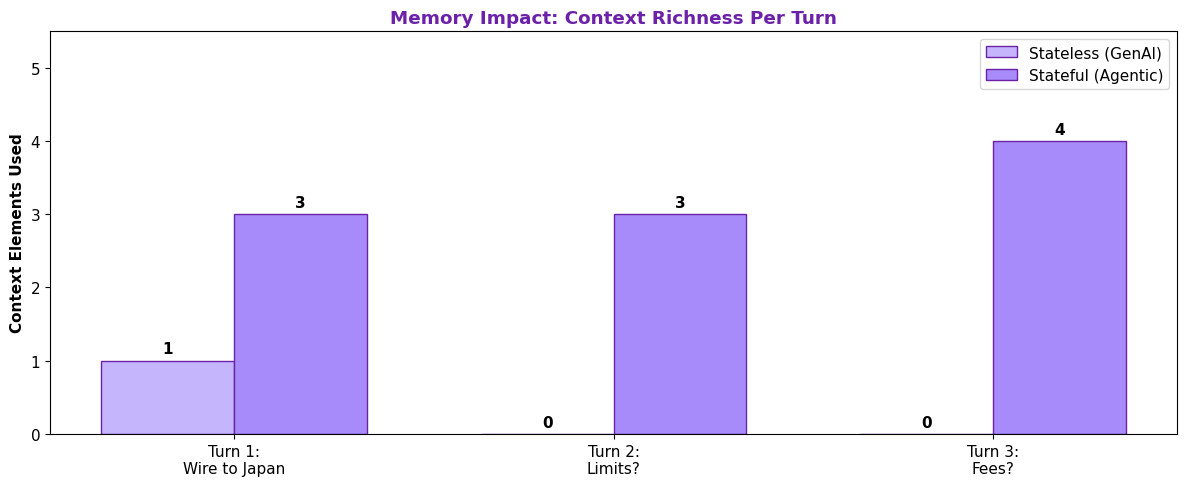

💡 Memory transforms generic Q&A into contextual, proactive assistance.


In [8]:
# === Stateless vs Stateful Conversation Simulation ===

class StatelessChat:
    """GenAI: No memory between turns."""
    def respond(self, message, history=None):
        # Without context, responses are generic
        if 'wire transfer' in message.lower():
            return 'Wire transfers are available. What currency and destination?'
        elif 'limits' in message.lower():
            return 'What type of account? What transaction type? I need more context.'
        elif 'fees' in message.lower():
            return 'Fees vary by account type, currency, and destination. Please specify.'
        return 'Could you provide more details?'

class StatefulChat:
    """Agentic: Memory retained across turns."""
    def __init__(self):
        self.memory = {}
    
    def respond(self, message):
        if 'wire transfer' in message.lower() and 'japan' in message.lower():
            self.memory['intent'] = 'international_wire'
            self.memory['destination'] = 'Japan'
            self.memory['context'] = 'business_supplier'
            return 'I can help with a JPY wire to Japan. Your business account supports this.'
        elif 'limits' in message.lower():
            # Uses memory!
            dest = self.memory.get('destination', 'unknown')
            return f'For international wires to {dest} from your business account: SGD 200,000/txn.'
        elif 'fees' in message.lower():
            dest = self.memory.get('destination', 'unknown')
            return f'For JPY wires to {dest}: SGD 25 + correspondent charges. Shall I initiate?'
        return 'How can I help?'

# Run both
messages = [
    'I want to send a wire transfer to my supplier in Japan',
    'What are the limits?',
    'And the fees?',
]

stateless = StatelessChat()
stateful = StatefulChat()

print('=' * 70)
print(f'{"STATELESS (GenAI)":^35} | {"STATEFUL (Agentic)":^35}')
print('=' * 70)

sl_responses = []
sf_responses = []

for msg in messages:
    sl = stateless.respond(msg)
    sf = stateful.respond(msg)
    sl_responses.append(sl)
    sf_responses.append(sf)
    print(f'\n👤 Customer: "{msg}"')
    print(f'   Stateless: {sl}')
    print(f'   Stateful:  {sf}')

# Visualize context richness
fig, ax = plt.subplots(figsize=(12, 5))

turns = ['Turn 1:\nWire to Japan', 'Turn 2:\nLimits?', 'Turn 3:\nFees?']
# Score: how many context elements are in the response
sl_context = [1, 0, 0]  # Generic, no context retention
sf_context = [3, 3, 4]  # Rich: destination, account type, currency, proactive offer

x = np.arange(len(turns))
width = 0.35

bars1 = ax.bar(x - width/2, sl_context, width, label='Stateless (GenAI)', 
              color=LIGHT_PURPLE, edgecolor=PURPLE)
bars2 = ax.bar(x + width/2, sf_context, width, label='Stateful (Agentic)', 
              color=ACCENT, edgecolor=PURPLE)

ax.set_ylabel('Context Elements Used', fontweight='bold')
ax.set_title('Memory Impact: Context Richness Per Turn', fontweight='bold', color=PURPLE)
ax.set_xticks(x)
ax.set_xticklabels(turns)
ax.legend()
ax.set_ylim(0, 5.5)

for bar, val in zip(bars1, sl_context):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val),
           ha='center', fontweight='bold')
for bar, val in zip(bars2, sf_context):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val),
           ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/home/claude/exp5_memory.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Memory transforms generic Q&A into contextual, proactive assistance.')

---
## 🔬 Experiment 6: Reflection — Self-Correction in Action

**Concept:** Agents evaluate their own output, detect issues, and regenerate — without human feedback.

We simulate a code generation agent that catches its own bugs.

🎯 Goal: Generate a payment validation function

📝 Attempt 1:
   def validate_payment(amount, currency):
    if amount > 0:
        return True
    return False

🔍 Reflection: Found 5 issues:
   ❌ No null/None handling
   ❌ No type validation
   ❌ Negative amounts not rejected (only checks > 0)
   ❌ No upper limit check
   ❌ No currency validation (ISO 4217)
   Quality Score: 0/100

📝 Attempt 2 (after self-correction):
   def validate_payment(amount, currency):
    if amount is None:
        raise ValueError("Amount cannot be null")
    if not isinstance(amount, (int, float)):
        raise TypeError("Amount must be numeric")
    if amount <= 0:
        raise ValueError("Amount must be positive")
    if amount > 1_000_000:
        raise ValueError("Amount exceeds limit")
    valid_currencies = ["USD","EUR","GBP","SGD","JPY"]
    if currency not in valid_currencies:
        raise ValueError(f"Invalid currency: {currency}")
    return True

🔍 Reflection: Found 0 issues
   Quality Score: 1

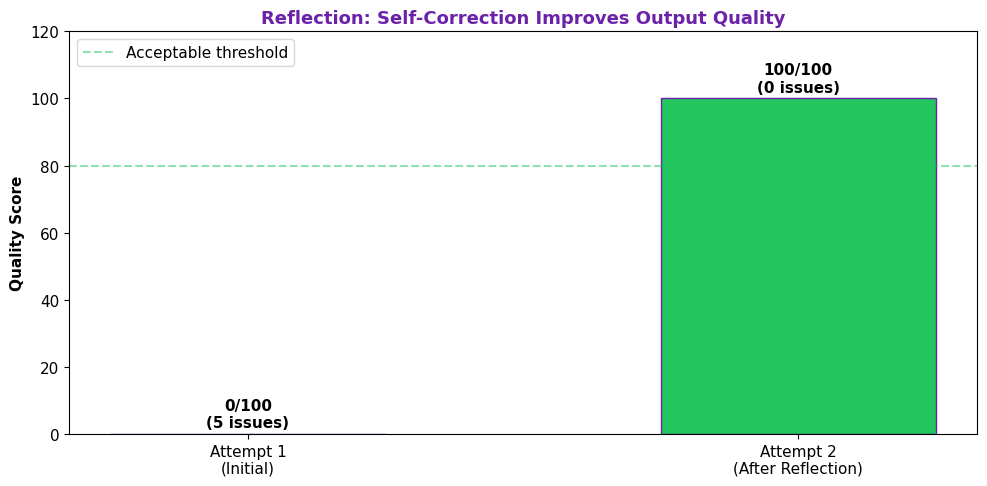

💡 Reflection = generate → check → fix. Eliminates common errors before human review.


In [9]:
# === Self-Correcting Code Agent ===

class CodeReflectionAgent:
    """Agent that generates code, self-evaluates, and improves."""
    
    def __init__(self):
        self.attempts = []
    
    def generate_payment_validator(self):
        print('🎯 Goal: Generate a payment validation function\n')
        
        # Attempt 1: Naive implementation
        attempt1 = {
            'code': '''def validate_payment(amount, currency):
    if amount > 0:
        return True
    return False''',
            'issues': [],
            'score': 0
        }
        
        # Reflection 1
        issues1 = self._reflect(attempt1['code'])
        attempt1['issues'] = issues1
        attempt1['score'] = max(0, 100 - len(issues1) * 20)
        self.attempts.append(attempt1)
        
        print('📝 Attempt 1:')
        print(f'   {attempt1["code"]}')
        print(f'\n🔍 Reflection: Found {len(issues1)} issues:')
        for issue in issues1:
            print(f'   ❌ {issue}')
        print(f'   Quality Score: {attempt1["score"]}/100')
        
        # Attempt 2: Fixed version
        attempt2 = {
            'code': '''def validate_payment(amount, currency):
    if amount is None:
        raise ValueError("Amount cannot be null")
    if not isinstance(amount, (int, float)):
        raise TypeError("Amount must be numeric")
    if amount <= 0:
        raise ValueError("Amount must be positive")
    if amount > 1_000_000:
        raise ValueError("Amount exceeds limit")
    valid_currencies = ["USD","EUR","GBP","SGD","JPY"]
    if currency not in valid_currencies:
        raise ValueError(f"Invalid currency: {currency}")
    return True''',
            'issues': [],
            'score': 0
        }
        
        issues2 = self._reflect(attempt2['code'])
        attempt2['issues'] = issues2
        attempt2['score'] = max(0, 100 - len(issues2) * 20)
        self.attempts.append(attempt2)
        
        print(f'\n📝 Attempt 2 (after self-correction):')
        print(f'   {attempt2["code"]}')
        print(f'\n🔍 Reflection: Found {len(issues2)} issues')
        print(f'   Quality Score: {attempt2["score"]}/100 ✅')
        
        return self.attempts
    
    def _reflect(self, code):
        """Self-evaluate code quality."""
        issues = []
        if 'None' not in code:
            issues.append('No null/None handling')
        if 'isinstance' not in code:
            issues.append('No type validation')
        if '<= 0' not in code and 'amount <= 0' not in code:
            issues.append('Negative amounts not rejected (only checks > 0)')
        if 'limit' not in code.lower() and '1_000_000' not in code:
            issues.append('No upper limit check')
        if 'currency' not in code or 'valid_currencies' not in code:
            issues.append('No currency validation (ISO 4217)')
        return issues


agent = CodeReflectionAgent()
results = agent.generate_payment_validator()

# Visualize improvement
fig, ax = plt.subplots(figsize=(10, 5))

attempts = ['Attempt 1\n(Initial)', 'Attempt 2\n(After Reflection)']
scores = [r['score'] for r in results]
issue_counts = [len(r['issues']) for r in results]

colors = [RED if s < 50 else ORANGE if s < 80 else GREEN for s in scores]
bars = ax.bar(attempts, scores, color=colors, edgecolor=PURPLE, width=0.5)

for bar, score, issues in zip(bars, scores, issue_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
           f'{score}/100\n({issues} issues)', ha='center', fontweight='bold', fontsize=11)

ax.set_ylim(0, 120)
ax.set_ylabel('Quality Score', fontweight='bold')
ax.set_title('Reflection: Self-Correction Improves Output Quality', 
             fontweight='bold', color=PURPLE, fontsize=13)
ax.axhline(y=80, color=GREEN, linestyle='--', alpha=0.5, label='Acceptable threshold')
ax.legend()

plt.tight_layout()
plt.savefig('/home/claude/exp6_reflection.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Reflection = generate → check → fix. Eliminates common errors before human review.')

---
## 🔬 Experiment 7: Cost & ROI Comparison Across 12 Use Cases

**Concept:** Agentic adds complexity and cost per task, but dramatically reduces time and labor cost.

We visualize the ROI data from all 12 banking use cases in the presentation.

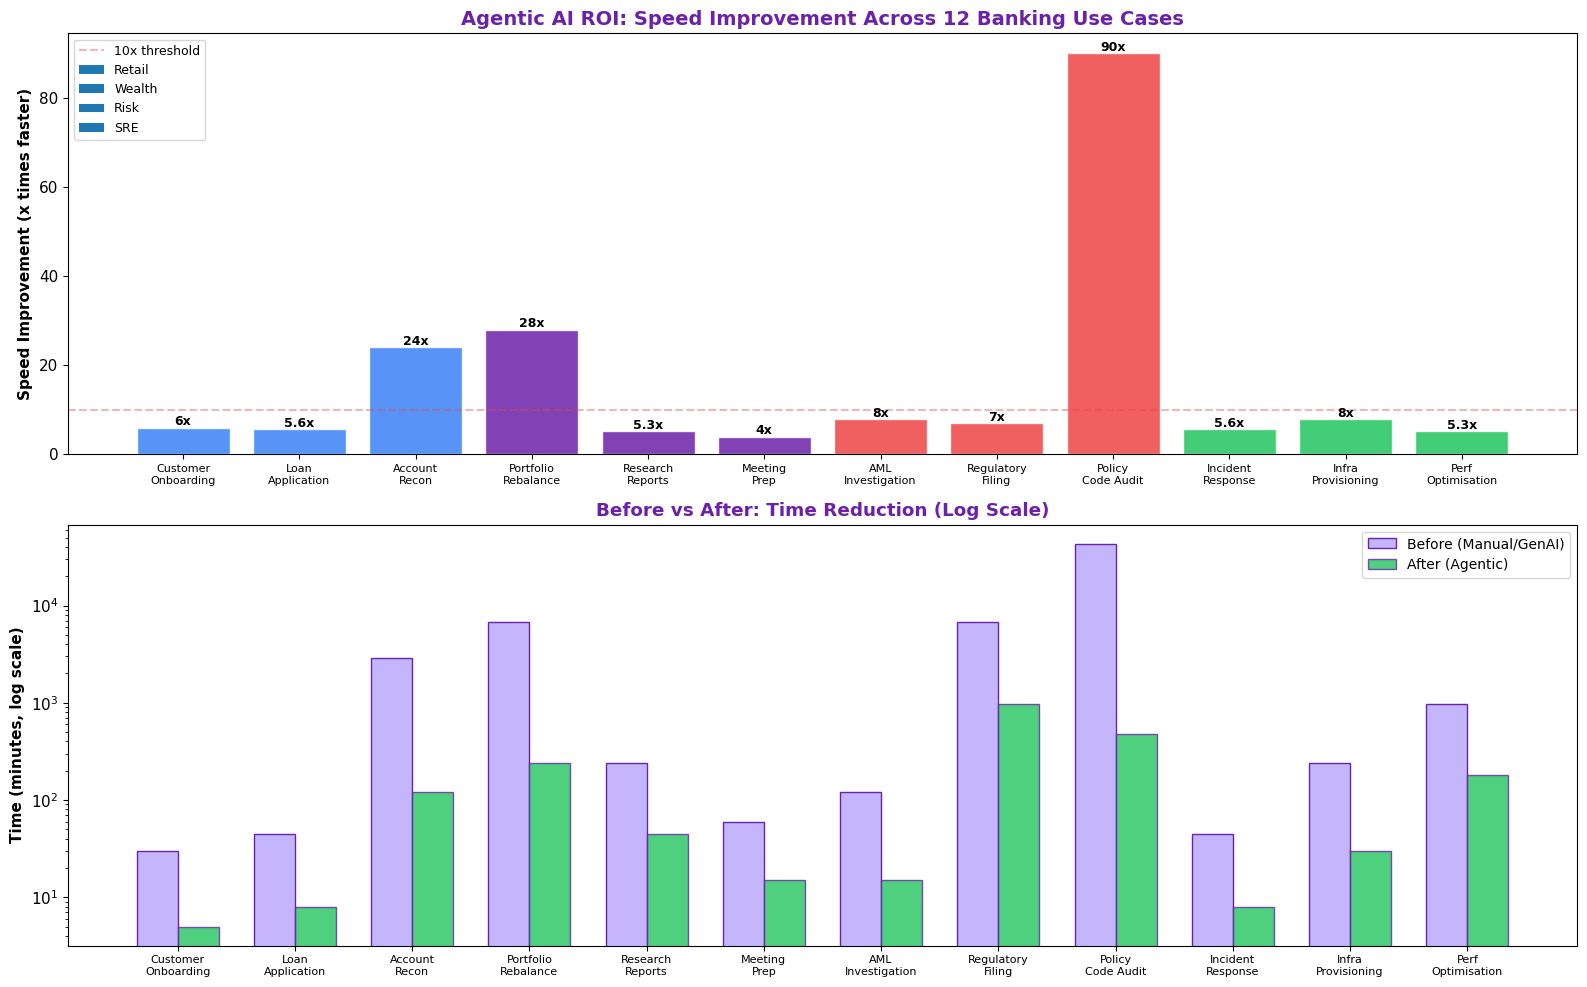

💡 Biggest wins: high-volume repetitive tasks (reconciliation, code audit, rebalancing).


In [10]:
# === ROI Comparison: All 12 Use Cases ===

use_case_data = [
    {'name': 'Customer\nOnboarding', 'domain': 'Retail', 'before_min': 30, 'after_min': 5, 'multiplier': 6},
    {'name': 'Loan\nApplication', 'domain': 'Retail', 'before_min': 45, 'after_min': 8, 'multiplier': 5.6},
    {'name': 'Account\nRecon', 'domain': 'Retail', 'before_min': 2880, 'after_min': 120, 'multiplier': 24},
    {'name': 'Portfolio\nRebalance', 'domain': 'Wealth', 'before_min': 6720, 'after_min': 240, 'multiplier': 28},
    {'name': 'Research\nReports', 'domain': 'Wealth', 'before_min': 240, 'after_min': 45, 'multiplier': 5.3},
    {'name': 'Meeting\nPrep', 'domain': 'Wealth', 'before_min': 60, 'after_min': 15, 'multiplier': 4},
    {'name': 'AML\nInvestigation', 'domain': 'Risk', 'before_min': 120, 'after_min': 15, 'multiplier': 8},
    {'name': 'Regulatory\nFiling', 'domain': 'Risk', 'before_min': 6720, 'after_min': 960, 'multiplier': 7},
    {'name': 'Policy\nCode Audit', 'domain': 'Risk', 'before_min': 43200, 'after_min': 480, 'multiplier': 90},
    {'name': 'Incident\nResponse', 'domain': 'SRE', 'before_min': 45, 'after_min': 8, 'multiplier': 5.6},
    {'name': 'Infra\nProvisioning', 'domain': 'SRE', 'before_min': 240, 'after_min': 30, 'multiplier': 8},
    {'name': 'Perf\nOptimisation', 'domain': 'SRE', 'before_min': 960, 'after_min': 180, 'multiplier': 5.3},
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# --- Top: Speed Improvement Multipliers ---
names = [d['name'] for d in use_case_data]
multipliers = [d['multiplier'] for d in use_case_data]
domains = [d['domain'] for d in use_case_data]
colors = [domain_colors[d] for d in domains]

bars = ax1.bar(range(len(names)), multipliers, color=colors, edgecolor='white', alpha=0.85)

for bar, mult in zip(bars, multipliers):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{mult}x', ha='center', fontweight='bold', fontsize=9)

ax1.set_xticks(range(len(names)))
ax1.set_xticklabels(names, fontsize=8)
ax1.set_ylabel('Speed Improvement (x times faster)', fontweight='bold')
ax1.set_title('Agentic AI ROI: Speed Improvement Across 12 Banking Use Cases', 
              fontweight='bold', color=PURPLE, fontsize=14)
ax1.axhline(y=10, color=RED, linestyle='--', alpha=0.4, label='10x threshold')

# Domain legend
for domain, color in domain_colors.items():
    ax1.bar([], [], color=color, label=domain)
ax1.legend(loc='upper left', fontsize=9)

# --- Bottom: Before vs After time (log scale for readability) ---
x = np.arange(len(names))
width = 0.35

before = [d['before_min'] for d in use_case_data]
after = [d['after_min'] for d in use_case_data]

ax2.bar(x - width/2, before, width, label='Before (Manual/GenAI)', 
       color=LIGHT_PURPLE, edgecolor=PURPLE)
ax2.bar(x + width/2, after, width, label='After (Agentic)', 
       color=GREEN, edgecolor=PURPLE, alpha=0.8)

ax2.set_yscale('log')
ax2.set_xticks(x)
ax2.set_xticklabels(names, fontsize=8)
ax2.set_ylabel('Time (minutes, log scale)', fontweight='bold')
ax2.set_title('Before vs After: Time Reduction (Log Scale)', 
              fontweight='bold', color=PURPLE)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('/home/claude/exp7_roi.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Biggest wins: high-volume repetitive tasks (reconciliation, code audit, rebalancing).')

---
## 🔬 Experiment 8: Decision Framework — Interactive Task Classifier

**Concept:** Use the Task Characteristics Matrix to classify any banking task as GenAI or Agentic.

We build a scoring function and test it against real scenarios.

💬 Email Response Draft: Score 0/8 → GenAI
🤖 Loan Application Review: Score 7/8 → AGENTIC AI
🤖 Account Reconciliation (10K): Score 8/8 → AGENTIC AI
💬 Code Explanation: Score 0/8 → GenAI
🤖 AML Investigation: Score 8/8 → AGENTIC AI
💬 Policy Q&A Lookup: Score 0/8 → GenAI


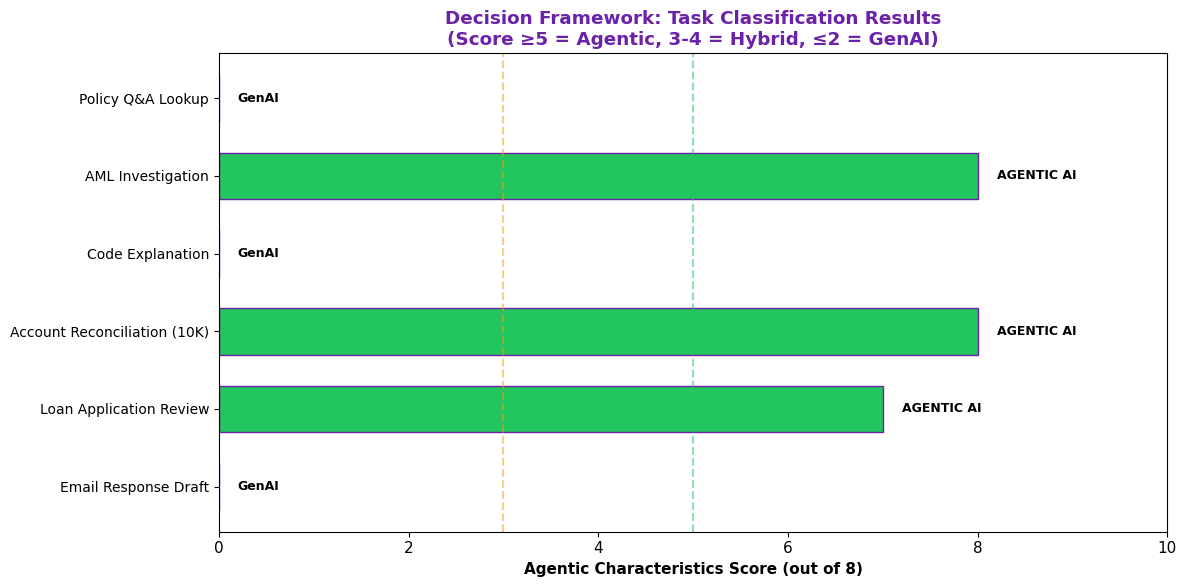


💡 Rule of thumb: 3+ agentic characteristics → invest in agentic approach.


In [11]:
# === Decision Framework: GenAI vs Agentic Classifier ===

def classify_task(task_name, characteristics):
    """
    Score a task based on 8 characteristics from the presentation.
    Each characteristic scored 0 (GenAI) or 1 (Agentic).
    
    characteristics: dict with keys:
        steps: 'single' or 'multi'
        tools: 'none' or 'ai_selected'
        planning: 'human' or 'ai'
        duration: 'seconds' or 'minutes+'
        state: 'stateless' or 'stateful'
        self_correction: 'no' or 'yes'
        volume: 'individual' or 'batch'
        error_tolerance: 'human_catches' or 'needs_guardrails'
    """
    score = 0
    details = []
    
    scoring = {
        'steps': ('single', 'multi'),
        'tools': ('none', 'ai_selected'),
        'planning': ('human', 'ai'),
        'duration': ('seconds', 'minutes+'),
        'state': ('stateless', 'stateful'),
        'self_correction': ('no', 'yes'),
        'volume': ('individual', 'batch'),
        'error_tolerance': ('human_catches', 'needs_guardrails'),
    }
    
    for key, (genai_val, agentic_val) in scoring.items():
        val = characteristics.get(key, genai_val)
        is_agentic = (val == agentic_val)
        score += int(is_agentic)
        details.append((key, val, '→ Agentic' if is_agentic else '→ GenAI'))
    
    if score >= 5:
        recommendation = 'AGENTIC AI'
    elif score >= 3:
        recommendation = 'HYBRID (Agentic + Human)'
    else:
        recommendation = 'GenAI'
    
    return {'task': task_name, 'score': score, 'recommendation': recommendation, 'details': details}


# Test with banking scenarios
scenarios = [
    ('Email Response Draft', {
        'steps': 'single', 'tools': 'none', 'planning': 'human',
        'duration': 'seconds', 'state': 'stateless', 'self_correction': 'no',
        'volume': 'individual', 'error_tolerance': 'human_catches'
    }),
    ('Loan Application Review', {
        'steps': 'multi', 'tools': 'ai_selected', 'planning': 'ai',
        'duration': 'minutes+', 'state': 'stateful', 'self_correction': 'yes',
        'volume': 'individual', 'error_tolerance': 'needs_guardrails'
    }),
    ('Account Reconciliation (10K)', {
        'steps': 'multi', 'tools': 'ai_selected', 'planning': 'ai',
        'duration': 'minutes+', 'state': 'stateful', 'self_correction': 'yes',
        'volume': 'batch', 'error_tolerance': 'needs_guardrails'
    }),
    ('Code Explanation', {
        'steps': 'single', 'tools': 'none', 'planning': 'human',
        'duration': 'seconds', 'state': 'stateless', 'self_correction': 'no',
        'volume': 'individual', 'error_tolerance': 'human_catches'
    }),
    ('AML Investigation', {
        'steps': 'multi', 'tools': 'ai_selected', 'planning': 'ai',
        'duration': 'minutes+', 'state': 'stateful', 'self_correction': 'yes',
        'volume': 'batch', 'error_tolerance': 'needs_guardrails'
    }),
    ('Policy Q&A Lookup', {
        'steps': 'single', 'tools': 'none', 'planning': 'human',
        'duration': 'seconds', 'state': 'stateless', 'self_correction': 'no',
        'volume': 'individual', 'error_tolerance': 'human_catches'
    }),
]

results = [classify_task(name, chars) for name, chars in scenarios]

# Print results
for r in results:
    emoji = '🤖' if 'AGENTIC' in r['recommendation'] else '🔀' if 'HYBRID' in r['recommendation'] else '💬'
    print(f'{emoji} {r["task"]}: Score {r["score"]}/8 → {r["recommendation"]}')

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

task_names = [r['task'] for r in results]
scores = [r['score'] for r in results]
recs = [r['recommendation'] for r in results]

color_map = {'GenAI': LIGHT_PURPLE, 'HYBRID (Agentic + Human)': ORANGE, 'AGENTIC AI': GREEN}
bar_colors = [color_map[r] for r in recs]

bars = ax.barh(range(len(task_names)), scores, color=bar_colors, 
              edgecolor=PURPLE, height=0.6)

for i, (bar, rec) in enumerate(zip(bars, recs)):
    ax.text(bar.get_width() + 0.2, i, rec, va='center', fontweight='bold', fontsize=9)

ax.set_yticks(range(len(task_names)))
ax.set_yticklabels(task_names, fontsize=10)
ax.set_xlabel('Agentic Characteristics Score (out of 8)', fontweight='bold')
ax.set_title('Decision Framework: Task Classification Results\n(Score ≥5 = Agentic, 3-4 = Hybrid, ≤2 = GenAI)', 
             fontweight='bold', color=PURPLE)
ax.axvline(x=3, color=ORANGE, linestyle='--', alpha=0.5)
ax.axvline(x=5, color=GREEN, linestyle='--', alpha=0.5)
ax.set_xlim(0, 10)

plt.tight_layout()
plt.savefig('/home/claude/exp8_decision_framework.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💡 Rule of thumb: 3+ agentic characteristics → invest in agentic approach.')

---
## 🔬 Experiment 9: Guardrails Simulation — Cost & Iteration Limits

**Concept:** Agentic systems need hard guardrails: max iterations, budget caps, kill switches.

We simulate a runaway agent and show how guardrails prevent cost overruns.

=== Guardrail Comparison ===

With Guardrails:
  Iterations: 11
  Total Cost: $0.55
  Stopped: BUDGET LIMIT ($0.5)

Without Guardrails:
  Iterations: 15
  Total Cost: $0.75
  Stopped: SUCCESS


/tmp/ipykernel_39/3241182682.py:91: UserWarning: Glyph 128721 (\N{OCTAGONAL SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_39/3241182682.py:91: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_39/3241182682.py:91: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_39/3241182682.py:91: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_39/3241182682.py:91: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_39/3241182682.py:92: UserWarning: Glyph 128721 (\N{OCTAGONAL SIGN}) missing from font(s) DejaVu Sans.
  plt.savefig('/home/claude/exp9_guardrails.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_39/3241182682.py:92: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128721 (\N{OCTAGONAL SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


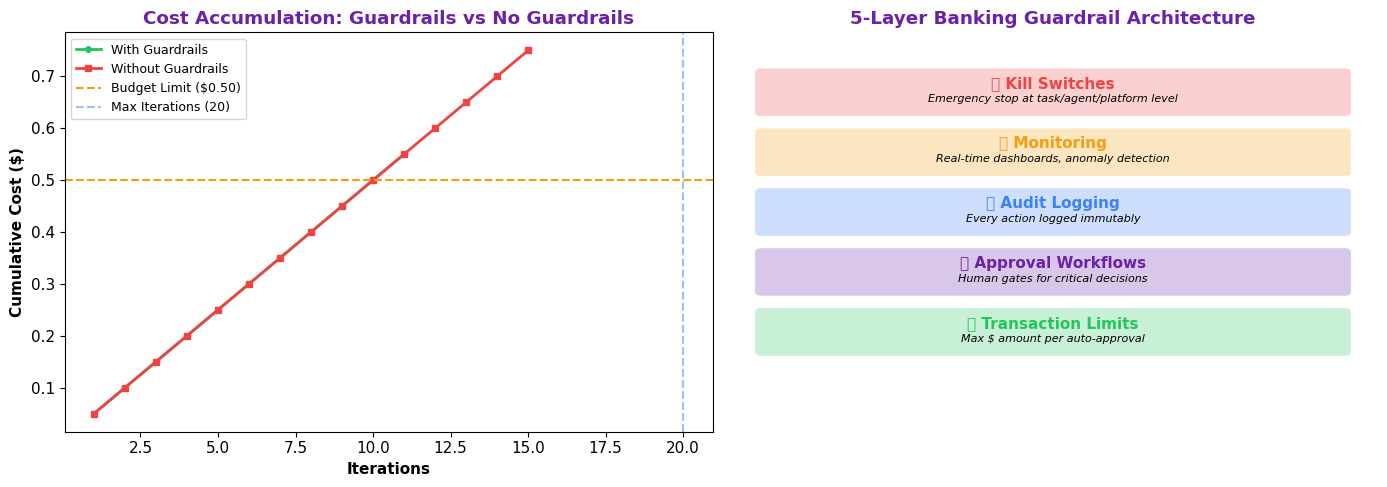

💡 Without guardrails, agents can burn through budgets on failed retries.


In [12]:
# === Guardrail Simulation: With vs Without Limits ===

def simulate_agent_run(max_iterations=None, budget_limit=None, has_guardrails=True):
    """Simulate an agent that encounters a failing tool and retries."""
    iterations = 0
    total_cost = 0
    cost_per_call = 0.05  # $0.05 per LLM call
    tool_fixed_at = 15  # Tool starts working at iteration 15
    log = []
    stopped_reason = None
    
    max_iter = max_iterations if has_guardrails else 200
    budget = budget_limit if has_guardrails else 999
    
    while iterations < max_iter and total_cost < budget:
        iterations += 1
        total_cost += cost_per_call
        
        # Tool fails until iteration 15
        success = iterations >= tool_fixed_at
        log.append({'iteration': iterations, 'cost': total_cost, 'success': success})
        
        if success:
            stopped_reason = 'SUCCESS'
            break
    
    if not stopped_reason:
        if iterations >= max_iter:
            stopped_reason = f'MAX ITERATIONS ({max_iter})'
        elif total_cost >= budget:
            stopped_reason = f'BUDGET LIMIT (${budget})'
    
    return {'iterations': iterations, 'cost': total_cost, 
            'reason': stopped_reason, 'log': log}


# Run with and without guardrails
guarded = simulate_agent_run(max_iterations=20, budget_limit=0.50, has_guardrails=True)
unguarded = simulate_agent_run(has_guardrails=False)  # Will run until success at iter 15
extreme = simulate_agent_run(max_iterations=200, budget_limit=999, has_guardrails=False)  
# Simulate what happens if tool NEVER fixes (change threshold)

print('=== Guardrail Comparison ===')
for name, result in [('With Guardrails', guarded), ('Without Guardrails', unguarded)]:
    print(f'\n{name}:')
    print(f'  Iterations: {result["iterations"]}')
    print(f'  Total Cost: ${result["cost"]:.2f}')
    print(f'  Stopped: {result["reason"]}')

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Cost accumulation over iterations
g_iters = [l['iteration'] for l in guarded['log']]
g_costs = [l['cost'] for l in guarded['log']]
u_iters = [l['iteration'] for l in unguarded['log']]
u_costs = [l['cost'] for l in unguarded['log']]

ax1.plot(g_iters, g_costs, 'o-', color=GREEN, label='With Guardrails', linewidth=2, markersize=4)
ax1.plot(u_iters, u_costs, 's-', color=RED, label='Without Guardrails', linewidth=2, markersize=4)
ax1.axhline(y=0.50, color=ORANGE, linestyle='--', label='Budget Limit ($0.50)')
ax1.axvline(x=20, color=BLUE, linestyle='--', alpha=0.5, label='Max Iterations (20)')

ax1.set_xlabel('Iterations', fontweight='bold')
ax1.set_ylabel('Cumulative Cost ($)', fontweight='bold')
ax1.set_title('Cost Accumulation: Guardrails vs No Guardrails', fontweight='bold', color=PURPLE)
ax1.legend(fontsize=9)

# Right: Guardrail architecture layers
ax2.axis('off')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_title('5-Layer Banking Guardrail Architecture', fontweight='bold', color=PURPLE)

layers = [
    ('🛑 Kill Switches', 'Emergency stop at task/agent/platform level', 8.5, RED),
    ('📊 Monitoring', 'Real-time dashboards, anomaly detection', 7, ORANGE),
    ('📝 Audit Logging', 'Every action logged immutably', 5.5, BLUE),
    ('✅ Approval Workflows', 'Human gates for critical decisions', 4, PURPLE),
    ('💰 Transaction Limits', 'Max $ amount per auto-approval', 2.5, GREEN),
]

for label, desc, y, color in layers:
    rect = FancyBboxPatch((0.5, y-0.5), 9, 1,
                          boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor='white', alpha=0.25)
    ax2.add_patch(rect)
    ax2.text(5, y + 0.1, label, ha='center', fontsize=11, fontweight='bold', color=color)
    ax2.text(5, y - 0.25, desc, ha='center', fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('/home/claude/exp9_guardrails.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Without guardrails, agents can burn through budgets on failed retries.')

---
## 🔬 Experiment 10: Migration Path Simulator

**Concept:** Teams progress from Pure GenAI → GenAI+Tools → Level 2 → Level 3 Agentic.

We model how capabilities and risk evolve through each phase.

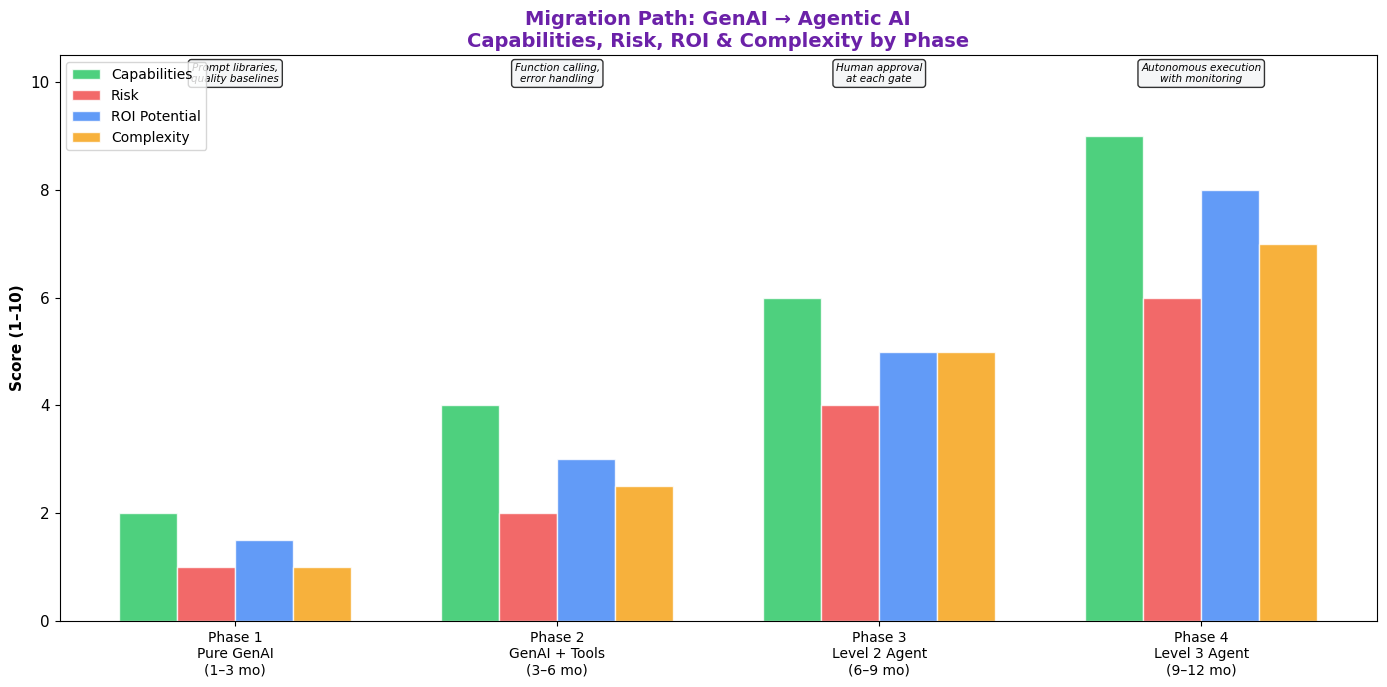

💡 Start with GenAI foundation. Build confidence before increasing autonomy.


In [13]:
# === Migration Path Visualization ===

phases = [
    {'name': 'Phase 1\nPure GenAI', 'months': '1–3', 
     'capabilities': 2, 'risk': 1, 'roi': 1.5, 'complexity': 1},
    {'name': 'Phase 2\nGenAI + Tools', 'months': '3–6',
     'capabilities': 4, 'risk': 2, 'roi': 3, 'complexity': 2.5},
    {'name': 'Phase 3\nLevel 2 Agent', 'months': '6–9',
     'capabilities': 6, 'risk': 4, 'roi': 5, 'complexity': 5},
    {'name': 'Phase 4\nLevel 3 Agent', 'months': '9–12',
     'capabilities': 9, 'risk': 6, 'roi': 8, 'complexity': 7},
]

fig, ax = plt.subplots(figsize=(14, 7))

categories = ['Capabilities', 'Risk', 'ROI Potential', 'Complexity']
colors_list = [GREEN, RED, BLUE, ORANGE]

x = np.arange(len(phases))
width = 0.18

for i, (cat, color) in enumerate(zip(categories, colors_list)):
    values = [p[cat.lower().replace(' ', '_').replace('_potential', '')] for p in phases]
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, values, width, label=cat, color=color, alpha=0.8, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([p['name'] + f'\n({p["months"]} mo)' for p in phases], fontsize=10)
ax.set_ylabel('Score (1–10)', fontweight='bold')
ax.set_title('Migration Path: GenAI → Agentic AI\nCapabilities, Risk, ROI & Complexity by Phase', 
             fontweight='bold', color=PURPLE, fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(0, 10.5)

# Add phase descriptions
descriptions = [
    'Prompt libraries,\nquality baselines',
    'Function calling,\nerror handling',
    'Human approval\nat each gate',
    'Autonomous execution\nwith monitoring'
]
for i, desc in enumerate(descriptions):
    ax.text(i, 10, desc, ha='center', fontsize=7.5, style='italic',
           bbox=dict(boxstyle='round', facecolor='#F3F4F6', alpha=0.8))

plt.tight_layout()
plt.savefig('/home/claude/exp10_migration.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Start with GenAI foundation. Build confidence before increasing autonomy.')

---
## ✅ Lab Summary

| Experiment | Concept | Key Takeaway |
|:--|:--|:--|
| 1. Execution Flow | GenAI vs Agentic architecture | Same outcome, fundamentally different who orchestrates |
| 2. Autonomy Spectrum | L0–L5 mapping | Banking sweet spot = L1–L3 |
| 3. Planning & Deps | Agent task decomposition | Parallel execution = massive time savings |
| 4. Tool Use & Errors | Error handling strategies | Retry → Fallback → Degrade → Escalate |
| 5. Memory | Stateless vs Stateful | Memory transforms generic Q&A into contextual assistance |
| 6. Reflection | Self-correction | Agents catch bugs before humans need to |
| 7. ROI Comparison | Cost-benefit across 12 cases | Biggest wins on high-volume repetitive tasks |
| 8. Decision Framework | Task classifier | Score ≥5 of 8 characteristics → go agentic |
| 9. Guardrails | Safety mechanisms | 5 layers: limits, approvals, logging, kill switches, monitoring |
| 10. Migration Path | Phased adoption | Start GenAI → add tools → Level 2 → Level 3 |

**Next Session (3 of 6):** RAG Architecture, Embeddings & Vector Databases